# Test

In [1]:
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from datasets import load_dataset
from PIL import Image
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoProcessor, AutoModel
import matplotlib.pyplot as plt

In [2]:
class VLM_Dataset(Dataset):
    def __init__(self, size=10000, filename = "Nano_Chimera.pkl", overwrite=False, seed=42):

        if os.path.exists(filename) and not overwrite:
            print(f"Dataset {filename} loaded!")
            with open(filename, "rb") as f:
                self.data = pickle.load(f)
        else:
            print("Downloading data...")
            stream = load_dataset(
                path = "damerajee/Llava-pretrain-small",
                split = "train",
                streaming = True
            ).shuffle(buffer_size=size, seed=seed)
        
            self.data = []
        
            for i, row in enumerate(stream):
                if i >= size:
                    break
                    
                self.data.append(self.extract_data(row))
                print(self.data)

            with open(filename, "wb") as f:
                pickle.dump(self.data, f)
                print(f"Dataset {filename} loaded!")
            
    def extract_data(self, line):
        return {
            "image": line["image"],
            "caption": line["answer"]
        }
        
    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

In [3]:
class VisionConnector(nn.Module):
    """
    Maps vision encoder features -> LLM embedding space
    Wide + shallow MLP (recommended)
    """
    def __init__(self, vision_dim, llm_dim, hidden_dim=4096):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(vision_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, llm_dim)
        )

    def forward(self, vision_feats):
        # vision_feats: (B, N, vision_dim)
        return self.proj(vision_feats)  # (B, N, llm_dim)


class SimpleVLM(nn.Module):
    """
    LLaVA-style VLM:
    - Frozen vision encoder
    - Frozen LLM
    - Trainable connector
    """
    def __init__(self, vision_encoder, llm, connector):
        super().__init__()
        self.vision = vision_encoder
        self.llm = llm
        self.connector = connector

        # Freeze vision + LLM
        self.vision.requires_grad_(False)
        self.llm.requires_grad_(False)

    def forward(
        self,
        images,                 # preprocessed images
        input_ids,              # text token IDs (with <image>)
        image_token_id,         # int
        labels=None
    ):
        """
        Returns LLM outputs (loss + logits)
        """

        # ---- vision ----
        with torch.no_grad():
            vision_feats = self.vision(images).last_hidden_state
            # (B, N, vision_dim)

        # ---- connector ----
        visual_tokens = self.connector(vision_feats)
        # (B, N, llm_dim)

        # ---- text embeddings ----
        text_embeds = self.llm.get_input_embeddings()(input_ids)
        # (B, T, llm_dim)

        # ---- replace <image> token with visual tokens ----
        B = input_ids.size(0)
        full_embeds = []

        for b in range(B):
            idx = (input_ids[b] == image_token_id).nonzero()[0].item()
            merged = torch.cat([
                text_embeds[b, :idx],
                visual_tokens[b],
                text_embeds[b, idx+1:]
            ], dim=0)
            full_embeds.append(merged)

        full_embeds = torch.stack(full_embeds, dim=0)

        # ---- LLM ----
        outputs = self.llm(
            inputs_embeds=full_embeds,
            labels=labels
        )

        return outputs

In [4]:
# ---------1) IMAGE → VISUAL TOKENS ---------
def encode_image(img, K=32):
    with torch.no_grad():
        inputs = vision_processor(images=img, return_tensors="pt").to(DEVICE)
        feats = vision_model.vision_model(**inputs).last_hidden_state  # shape: [1, seq_len, vision_dim]
        feats = feats[:, :K, :]  # truncate to K tokens
    return connector(feats)   # project to LLM dim

# ---------2) BUILD MULTIMODAL EMBEDDINGS ---------
def build_inputs(img, text, K):
    vis_embeds = encode_image(img, K)  # [1, K, llm_dim]
    text_input = f"{IMAGE_TOKEN} {text}"
    ids = tokenizer(text_input, return_tensors="pt").input_ids.to(DEVICE)
    text_embeds = llm.get_input_embeddings()(ids)

    # replace IMAGE_TOKEN with visual embeddings
    idx = (ids == tokenizer.convert_tokens_to_ids(IMAGE_TOKEN)).nonzero()[0, 1]
    embeds = torch.cat([text_embeds[:, :idx], vis_embeds, text_embeds[:, idx + 1:]], dim=1)
    attention_mask = torch.ones(embeds.size()[:-1], device=DEVICE)
    return embeds, attention_mask, idx

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------3) LOAD DATA ---------
# data = VLM_Dataset(size=5, overwrite=True)
data = VLM_Dataset()

# ---------4) LOAD MODELS (FROZEN) ---------
LLM_NAME = "Qwen/Qwen2.5-0.5B"
VISION_NAME = "google/siglip-base-patch16-224"

tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME, dtype=torch.float16
).to(DEVICE)
llm.requires_grad_(False)
llm.eval()

vision_processor = AutoProcessor.from_pretrained(VISION_NAME, use_fast=True)
vision_model = AutoModel.from_pretrained(
    VISION_NAME, dtype=torch.float16
).to(DEVICE)
vision_model.requires_grad_(False)
vision_model.eval()

# ---------5) ADD IMAGE TOKEN ---------
IMAGE_TOKEN = "<image>"
if IMAGE_TOKEN not in tokenizer.get_vocab():
    tokenizer.add_special_tokens({"additional_special_tokens": [IMAGE_TOKEN]})
    llm.resize_token_embeddings(len(tokenizer))

Dataset Nano_Chimera.pkl loaded!


In [6]:
# ---------6) CONNECTOR (SHALLOW MLP) ---------
# SigLIP output dimension
vision_dim = vision_model.config.vision_config.hidden_size
llm_dim = llm.config.hidden_size

connector = VisionConnector(
    vision_dim=vision_dim,
    llm_dim=llm_dim,
    hidden_dim=48828
).to(DEVICE).half()

vlm = SimpleVLM(
    vision_encoder=vision_model.vision_model,
    llm=llm,
    connector=connector
).to(DEVICE)

# ---------7) TRAIN STEP (ALIGNMENT) ---------
optimizer = torch.optim.AdamW(connector.parameters(), lr=1e-3)

img = data[0]["image"]
caption = data[0]["caption"]
K = 32

labels = tokenizer(caption, return_tensors="pt").input_ids.to(DEVICE)
inputs_embeds, attention_mask, idx = build_inputs(img, caption, K)

labels = torch.cat([
    labels[:, :idx],  # text before image
    torch.full((1, K), -100, device=DEVICE, dtype=labels.dtype),  # ignore image tokens
    labels[:, idx:]  # text after image
], dim=1)

out = vlm.llm(inputs_embeds=inputs_embeds, attention_mask=attention_mask, labels=labels)
loss = out.loss

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Loss:", loss.item())

Loss: 9.456212997436523


Answer:  and durable. They are made of high-quality materials and are designed to withstand the rigors of outdoor activities. They are also available in a variety of colors and styles to suit your personal style. They
Caption: a large umbrella that is open with the side end closed


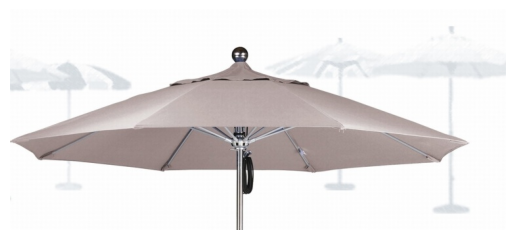

In [7]:
# ---------8) INFERENCE TEST ---------
img = data[1]["image"]

with torch.no_grad():
    prompt = "What is in this image?"
    embeds = build_inputs(img, prompt, K)
    generated = vlm.llm.generate(inputs_embeds=inputs_embeds, max_new_tokens=40, attention_mask=attention_mask, pad_token_id=tokenizer.pad_token_id)

print(f"Answer: {tokenizer.decode(generated[0], skip_special_tokens=True)}")
print(f"Caption: {data[1]["caption"]}")
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
llm.config

Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "float16",
  "eos_token_id": 151643,
  "hidden_act": "silu",
  "hidden_size": 896,
  "initializer_range": 0.02,
  "intermediate_size": 4864,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention"
  ],
  "max_position_embeddings": 32768,
  "max_window_layers": 24,
  "model_type": "qwen2",
  "num_attention_heads": 14,
  "num_hidden_layers": 24,
  "num_key_value_heads": 2,
  "rms_n